In [1]:
import math, numpy as np, numpy.linalg as LA, networkx as nx, matplotlib.pyplot as plt, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from tqdm.notebook import tqdm
import pmdarima as pm
import joblib  # To save models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
CONFIG = {
    # Date_Range that will be used to generate the temporal features 
    "START_DATE": "2024-01-01",
    "FREQUENCY": "H",                 
    
    # Dataset
    "DATA_PATH": "path/to/gridfm_data/raw", 
    
    # Features
    "USE_ONLY_LOAD": True,              # Only use active load P
    "BINARY_ADJACENCY": True,           # True = Graph is 0/1 (no admittance)
    
    # Splitting (Interleaved 4:1:1 Strategy)
    "BLOCK_SIZE_HOURS": 168,            # 1 Woche
    "CYCLE_SCHEME": 6,                  #! Function is not truly dynamicly coded
    
    # Forecasting  (Triebe et al. Logic)
    "INPUT_WINDOW": 168,                # Lookback: 7 Tage
    "FORECAST_HORIZON": 33,             # Predict: Rest of Day (9h) + Next Day (24h)
    "TARGET_DAY_START_IDX": 9,          # Target Day" (00:00 tmrw)
    "EVAL_HOUR": 14,                    # forecasting is done always at 2pm    
    # Baselines
    "SNAIVE_LAG": 48                    # Benchmark: value 48h ago
}

In [3]:
#! Set working dir
import os
print(os.getcwd())
os.chdir("../")
print(os.getcwd())

f:\studium\Thesis_Repo\phase1_tgt_model
f:\studium\Thesis_Repo


In [4]:
# Load Bus and Branch DataFrames

bus_df = pd.read_parquet('data_out/no_pertubations/case14_ieee/raw/bus_data.parquet')
branch_df = pd.read_parquet('data_out/no_pertubations/case14_ieee/raw/branch_data.parquet')

# Build Edge Index from Branch Data
structure = branch_df[branch_df['load_scenario_idx'] == 0].sort_values("idx")
edge_index = list(structure[['from_bus', 'to_bus']].itertuples(index=False, name=None))

# print dims
m = len(edge_index)
n=bus_df['bus'].nunique()
print(f"Topology Loaded: n={n} Nodes, m={m} Edges")

# X: Input Loads (Active Power 'Pd')
loads_pivot = bus_df.pivot(index='load_scenario_idx', columns='bus', values='Pd').fillna(0)
# Y: Target Flows (Active Power Flow 'pf')
flows_pivot = branch_df.pivot(index='load_scenario_idx', columns='idx', values='pf').fillna(0)

# Convert to Numpy Arrays
loads_matrix = loads_pivot.values.astype(np.float32)
flows_matrix = flows_pivot.values.astype(np.float32)
print(f"shapes: Loads: {loads_matrix.shape}, Flows: {flows_matrix.shape}")

# Adjacency mask (neighbors + self)
A = np.zeros((n,n), dtype=bool)
for (i,j) in edge_index:
    A[i,j]=True; A[j,i]=True
for i in range(n): A[i,i]=True
A_mask = torch.from_numpy(A).to(device)

Topology Loaded: n=14 Nodes, m=20 Edges
shapes: Loads: (8760, 14), Flows: (8760, 20)


In [5]:
def generate_cyclical_features(T):
    """
    Generates global temporal features 
    Returns: matrix: [T, 6].
    """
    dates = pd.date_range(start=CONFIG["START_DATE"], periods=T, freq=CONFIG["FREQUENCY"])
    df_time = pd.DataFrame({'date': dates})
    hour = df_time['date'].dt.hour
    dow  = df_time['date'].dt.dayofweek
    doy  = df_time['date'].dt.dayofyear
    
    # Sin/Cos Encoding 
    df_time['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    df_time['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)   
    df_time['dow_sin'] = np.sin(2 * np.pi * dow / 7.0)
    df_time['dow_cos'] = np.cos(2 * np.pi * dow / 7.0)
    df_time['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    df_time['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    
    feature_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']
    return df_time[feature_cols].values.astype(np.float32)



In [6]:
def get_interleaved_splits(T):
    """
    Implements repeated 4:1:1 Splitting.
        # 0,1,2,3 -> Train
        # 4       -> Val
        # 5       -> Test    
    Returns:
        train_idx, val_idx, test_idx (arrays of time steps)
    """
    n_blocks = T // CONFIG["BLOCK_SIZE_HOURS"]
    
    train_indices = []
    val_indices = []
    test_indices = []
    
    for i in range(n_blocks):
        start_t = i * CONFIG["BLOCK_SIZE_HOURS"]
        end_t = start_t + CONFIG["BLOCK_SIZE_HOURS"]
        cycle_pos = i % CONFIG["CYCLE_SCHEME"]
        block_range = np.arange(start_t, end_t)
        
        if cycle_pos in [0, 1, 2, 3]:
            train_indices.extend(block_range)
            
        elif cycle_pos == 4:
            if start_t >= CONFIG["INPUT_WINDOW"]:
                val_indices.extend(block_range)
            else: 
                train_indices.extend(block_range) # Fallback
                
        elif cycle_pos == 5:
            if start_t >= CONFIG["INPUT_WINDOW"]:
                test_indices.extend(block_range)
            else:
                train_indices.extend(block_range)
    return np.array(train_indices), np.array(val_indices), np.array(test_indices)




In [7]:
def scale_data_selectively(full_data, train_indices):
    scaler = StandardScaler()
    scaler.fit(full_data[train_indices, :, 0].reshape(-1, 1)) # Fit on feature 0 using train time steps
    full_data_scaled = full_data.copy()

    # Scale feature 0  in whole dataset
    full_data_scaled[:, :, 0] = scaler.transform(
        full_data[:, :, 0].reshape(-1, 1)
    ).reshape(full_data.shape[0], full_data.shape[1])

    return full_data_scaled.astype(np.float32), scaler

In [8]:
class RollingDataset(Dataset):
    def __init__(self, data, split_indices, input_window, forecast_horizon):
        """
        Args:
            data: Scaled Tensor [T, N, F]
            split_indices: Array of valid start times (e.g. train_idx)
            input_window: Int (e.g 168)
            forecast_horizon: Int (e.g 33)
        """
        self.data = data
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        
        # Create a boolean mask for the global timeline
        valid_mask = np.zeros(self.data.shape[0], dtype=bool)
        valid_mask[split_indices] = True
        # Apply boundary constraints
        valid_mask[:input_window] = False  # Start: Must be >= input_window 
        if forecast_horizon > 0: 
            valid_mask[-forecast_horizon:] = False # End: Must have space for 33h horizon
        self.valid_starts = np.where(valid_mask)[0] # [valid t indices]

    def __len__(self):
        return len(self.valid_starts)

    def __getitem__(self, idx):
        t = self.valid_starts[idx] # t = time step where Prediction STARTS (Forecast Hour 0
        x = self.data[t - self.input_window : t] # Input X: History [t-168 ... t-1] 
        y = self.data[t : t + self.forecast_horizon] # Target Y: Future [t ... t+33-1] 
        
        return torch.from_numpy(x), torch.from_numpy(y)

In [9]:
# --- Prepare Input Tensor X --- 
# 1. gen Time Features 
T = loads_matrix.shape[0]
time_features_global = generate_cyclical_features(T) # [T, 6]
print(f"Time Features generated. Shape: {time_features_global.shape}")

# 2. gen input tensor X
load_tensor = loads_matrix[:, :, np.newaxis]  # [T, N] -> [T, N, 1]
time_tensor_expanded = np.broadcast_to(
    time_features_global[:, np.newaxis, :], 
    (time_features_global.shape[0], loads_matrix.shape[1], time_features_global.shape[1])
) # [T, 6] -> [T, N, 6]  (*read-only view)
X = np.concatenate([load_tensor, time_tensor_expanded], axis=2) # [T, N, 1] + [T, N, 6] -> [T, N, 7]
print(f"Final Input Tensor Shape: {X.shape} (Time, Buses, Features)")

# --- Split Data ---
train_idx, val_idx, test_idx = get_interleaved_splits(T)
print(f"Train Hours: {len(train_idx)}")
print(f"Val Hours:   {len(val_idx)}")
print(f"Test Hours:  {len(test_idx)}")

# --- 3. Scaling (Selective) ---
scaled_tensor, scaler = scale_data_selectively(X, train_idx)
print(f"Scaled Mean (Load): {scaled_tensor[:,:,0].mean():.4f}")
print(f"Scaled Mean (Hour_Sin): {scaled_tensor[:,:,1].mean():.4f} (Should be near 0 but unscaled)")

# --- 4. Create Datasets & Loaders ---
train_dataset = RollingDataset(scaled_tensor, train_idx, CONFIG["INPUT_WINDOW"], CONFIG["FORECAST_HORIZON"])
val_dataset   = RollingDataset(scaled_tensor, val_idx,   CONFIG["INPUT_WINDOW"], CONFIG["FORECAST_HORIZON"])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

# --- 5. Test One Batch ---
x_batch, y_batch = next(iter(train_loader))
print(f"\nBatch Shapes:")
print(f"X (Input):  {x_batch.shape}  -> [Batch, 168, 14, 7]")
print(f"Y (Target): {y_batch.shape}   -> [Batch, 33, 14, 7]")

C:\Users\monst\AppData\Local\Temp\ipykernel_4576\4199759783.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=CONFIG["START_DATE"], periods=T, freq=CONFIG["FREQUENCY"])


Time Features generated. Shape: (8760, 6)
Final Input Tensor Shape: (8760, 14, 7) (Time, Buses, Features)
Train Hours: 6048
Val Hours:   1344
Test Hours:  1344
Scaled Mean (Load): -0.0003
Scaled Mean (Hour_Sin): 0.0000 (Should be near 0 but unscaled)

Batch Shapes:
X (Input):  torch.Size([4, 168, 14, 7])  -> [Batch, 168, 14, 7]
Y (Target): torch.Size([4, 33, 14, 7])   -> [Batch, 33, 14, 7]


In [10]:
class SNaiveModel:
    def __init__(self, lag=48):
        self.lag = lag

    def predict(self, history):
        if len(history) < self.lag:
            raise ValueError("History shorter than lag!")
        return history[-self.lag : -self.lag + CONFIG["FORECAST_HORIZON"]]


In [21]:
# XGBOOST

def prepare_xgb_data(full_data_scaled, indices, input_window, forecast_horizon, step_size):
    """
    Args:
        step_size: only train on every step_size-th index
    """
    T, N_buses, F = full_data_scaled.shape
    n_time_feats = F - 1  # exclude load
    valid_indices = [t for t in indices if t >= input_window and t <= T - forecast_horizon]
    sampled_indices = valid_indices[::step_size]  #*  Downsampling for RAM
    
    n_samples = len(sampled_indices) * N_buses
    # input_window lags + time features + 1 bus id
    n_features = input_window + n_time_feats + 1
    print(f"Allocating RAM for {n_samples} samples...")
    
    X = np.empty((n_samples, n_features), dtype=np.float32)
    Y = np.empty((n_samples, forecast_horizon), dtype=np.float32)
    
    row_idx = 0
    for t in tqdm(sampled_indices, desc="Building XGB Dataset"):
        time_feats = full_data_scaled[t, 0, 1:]  # length = n_time_feats
        
        for bus in range(N_buses):
            lags = full_data_scaled[t-input_window:t, bus, 0]
            
            X[row_idx, :input_window] = lags
            X[row_idx, input_window : input_window+n_time_feats] = time_feats
            X[row_idx, input_window+n_time_feats] = bus
            
            Y[row_idx, :] = full_data_scaled[t : t+forecast_horizon, bus, 0]
            
            row_idx += 1
            
    return X, Y
# 1. Prepare Data mit Downsampling
# step_size=4 bedeutet: Wir nutzen 25% der Daten. Das reicht als Baseline völlig.
X_train_xgb, Y_train_xgb = prepare_xgb_data(
    scaled_tensor, 
    train_idx, 
    CONFIG["INPUT_WINDOW"], 
    CONFIG["FORECAST_HORIZON"],
    step_size=1  # <--- WICHTIG: RAM sparen
)

print(f"XGB Train Shape: {X_train_xgb.shape}")

# 2. Setup GPU XGBoost
xgb_estimator = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective='reg:squarederror',
    # GPU Konfiguration für GTX 970:
    device='cuda',       
    tree_method='hist',  # 'hist' ist auf GPU extrem schnell
    n_jobs=4             # CPU Threads für Daten-Loading
)

# 3. Wrapper
xgb_model = MultiOutputRegressor(xgb_estimator, n_jobs=1) # n_jobs=1 -> sequential training 

# 4. Fit
print("Training Global XGBoost on GTX 970...")
xgb_model.fit(X_train_xgb, Y_train_xgb)
print("XGBoost Training Complete.")

Allocating RAM for 82208 samples...


Building XGB Dataset:   0%|          | 0/5872 [00:00<?, ?it/s]

XGB Train Shape: (82208, 175)
Training Global XGBoost on GTX 970...
XGBoost Training Complete.


In [16]:
import torch
import torch.nn as nn
import math
import torch.optim as optim

# --- UNVERÄNDERT ---
class SpatialAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__(); self.h=n_heads; self.dk=d_model//n_heads
        self.q=nn.Linear(d_model,d_model); self.k=nn.Linear(d_model,d_model); self.v=nn.Linear(d_model,d_model); self.o=nn.Linear(d_model,d_model)
    def forward(self, x, mask):
        B,N,D = x.shape; H=self.h; dk=self.dk
        q=self.q(x).view(B,N,H,dk).transpose(1,2)
        k=self.k(x).view(B,N,H,dk).transpose(1,2)
        v=self.v(x).view(B,N,H,dk).transpose(1,2)
        s=(q@k.transpose(-2,-1))/math.sqrt(dk)
        m = mask.unsqueeze(0).unsqueeze(0).expand(B,H,N,N)
        s = s.masked_fill(~m, float('-inf'))
        a = torch.softmax(s, dim=-1)
        out = a@v
        out = out.transpose(1,2).contiguous().view(B,N,D)
        return self.o(out)

class TemporalBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff  = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Linear(4*d_model, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        y,_ = self.attn(x,x,x); x=self.ln1(x+y)
        y = self.ff(x); x=self.ln2(x+y); return x

# --- ANGEPASST FÜR FORECASTING ---
class TinyTGT(nn.Module):
    def __init__(self, n_nodes, d_model=64, n_heads=4, n_temporal_layers=2, in_feat=7, out_steps=33):
        super().__init__()
        self.n_nodes = n_nodes
        
        # ÄNDERUNG 1: Input Projektion (7 Features -> d_model)
        self.enc = nn.Linear(in_feat, d_model)
        
        self.spat = SpatialAttention(d_model, n_heads)
        self.temporal = nn.ModuleList([TemporalBlock(d_model, n_heads) for _ in range(n_temporal_layers)])
        
        # ÄNDERUNG 2: Node Decoder statt Edge MLP
        # Wir wollen pro Node 33 Werte vorhersagen
        self.node_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, out_steps) # Output: 33 Stunden
        )
        
        # (src/dst Buffer entfernt, da wir Nodes vorhersagen, keine Kanten)

    def forward(self, x, mask):
        # x: (B, T, N, 7)  <-- Input hat jetzt 7 Features
        B, T, N, F = x.shape
        
        # Encoding: (B*T*N, 7) -> (B*T*N, D) -> (B, T, N, D)
        x_emb = self.enc(x.reshape(B*T*N, F)).view(B, T, N, -1)
        
        # Spatial attention per time
        # Flatten Time: (B*T, N, D)
        x_spat = self.spat(x_emb.view(B*T, N, -1), mask).view(B, T, N, -1)
        
        # Temporal attention per node
        # Permute zu (B*N, T, D) damit Attention über Zeit läuft
        x_temp = x_spat.permute(0,2,1,3).contiguous().view(B*N, T, -1)
        
        for layer in self.temporal:
            x_temp = layer(x_temp)
            
        # Nimm den letzten Zeitschritt T
        hT = x_temp[:, -1, :] # (B*N, D)
        
        # ÄNDERUNG 3: Node Readout
        out = self.node_decoder(hT) # (B*N, 33)
        
        # Reshape zurück zu (B, 33, N) für Loss Berechnung
        # (B*N, 33) -> (B, N, 33) -> (B, 33, N)
        return out.view(B, N, -1).transpose(1, 2)
    
# Setup
import gc

# 1. GPU Speicher aufräumen
if 'model' in locals():
    del model
if 'opt' in locals():
    del opt
gc.collect()
torch.cuda.empty_cache() 

# 2. Modell neu initialisieren (Kleiner Trick: wir gehen auf Float32 sicher)
model = TinyTGT(n_nodes=14, d_model=64, n_heads=4, in_feat=7, out_steps=33).to(device)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
epochs = 15 

print(f"Restarting TinyTGT Training (Batch Size {4})...")

# 3. Training Loop (Exakt wie vorher)
for ep in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    batch_count = 0
    
    for xb, yb in train_loader:
        xb = xb.float().to(device) 
        yb = yb.float().to(device) 
        
        opt.zero_grad()
        
        # Forward
        yhat = model(xb, A_mask) 
        
        y_true = yb[..., 0] # Target Slicing
        
        loss = loss_fn(yhat, y_true)
        loss.backward()
        opt.step()
        
        train_loss += loss.item()
        batch_count += 1
    
    avg_train_loss = train_loss / batch_count
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.float().to(device)
            y_true = yb[..., 0].float().to(device)
            
            yhat = model(xb, A_mask)
            val_loss += loss_fn(yhat, y_true).item()
            val_batches += 1
            
    print(f"Epoch {ep}: Train MSE={avg_train_loss:.6f} | Val MSE={val_loss/val_batches:.6f}")

Restarting TinyTGT Training (Batch Size 4)...
Epoch 1: Train MSE=0.037417 | Val MSE=0.018243
Epoch 2: Train MSE=0.010948 | Val MSE=0.010178
Epoch 3: Train MSE=0.008342 | Val MSE=0.009149
Epoch 4: Train MSE=0.007524 | Val MSE=0.011439
Epoch 5: Train MSE=0.006981 | Val MSE=0.009343
Epoch 6: Train MSE=0.006429 | Val MSE=0.009343
Epoch 7: Train MSE=0.005782 | Val MSE=0.010842
Epoch 8: Train MSE=0.005606 | Val MSE=0.009047
Epoch 9: Train MSE=0.005078 | Val MSE=0.009294
Epoch 10: Train MSE=0.004510 | Val MSE=0.008940
Epoch 11: Train MSE=0.004900 | Val MSE=0.008395
Epoch 12: Train MSE=0.004278 | Val MSE=0.009446
Epoch 13: Train MSE=0.003859 | Val MSE=0.009435
Epoch 14: Train MSE=0.005201 | Val MSE=0.009478
Epoch 15: Train MSE=0.004057 | Val MSE=0.009628


In [24]:
# ...existing code...
# --- 1. ROBUST SARIMA WRAPPER ---
class GlobalFitLocalApplySARIMA:
    def __init__(self, order=(2, 0, 0), seasonal_order=(1, 0, 1, 24)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.bus_params = {} # Stores the fitted result wrapper per bus
        self.failure_count = 0 
        self.call_count = 0

    def fit(self, full_data, train_indices):
        """
        Fits 14 separate models (Local) on a contiguous chunk of Training Data.
        We use the first 4 weeks (672h) of training data to estimate parameters.
        """
        print("Fitting SARIMA Parameters per Bus (Local Training)...")
        # Find a contiguous block in train_indices to avoid 'jumps' in time
        # We assume the first block is at least 4 weeks.
        train_limit = 168 * 4 
        # Check if we have enough contiguous data at the start
        valid_train_range = train_indices[train_indices < train_limit]
        
        if len(valid_train_range) == 0:
            # Fallback if indices are weird
            train_block_idx = train_indices[:train_limit]
        else:
            train_block_idx = valid_train_range

        dataset_subset = full_data[train_block_idx, :, 0] # [T_sub, N_buses]
        
        for b in tqdm(range(full_data.shape[1]), desc="Fitting Bus Models"):
            try:
                # Fit on the training block
                model = SARIMAX(
                    dataset_subset[:, b],
                    order=self.order,
                    seasonal_order=self.seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                # 'powell' is robust; disp=False hides logs
                self.bus_params[b] = model.fit(disp=False, method='powell')
            except Exception as e:
                print(f"⚠️ Fit failed for Bus {b}: {e}")
                self.bus_params[b] = None

    def predict(self, history, bus_idx, horizon=33):
        """
        Uses pre-learned parameters to filter the new 'history' window and forecast.
        """
        self.call_count += 1
        model_res = self.bus_params.get(bus_idx)
        
        if model_res is None:
            self.failure_count += 1
            return self._naive_fallback(history, horizon)
        
        try:
            # .apply() updates the state (Kalman Filter) with the new observation window
            # using the frozen parameters from training.
            new_res = model_res.apply(history)
            return new_res.forecast(steps=horizon)
        except:
            self.failure_count += 1
            return self._naive_fallback(history, horizon)

    def _naive_fallback(self, history, horizon):
        return np.resize(history[-24:], horizon)

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import numpy as np
from tqdm.notebook import tqdm

# --- 1. NEW HELPER: Calculate MASE/MSSE Denominators ---
def get_scaling_factors(full_data, train_idx, scaler, m=24):
    """
    Berechnet den Fehler der Seasonal Naive Methode (Lag m) auf dem TRAINING-Set.
    Das ist die Basis (Nenner) für MASE und MSSE.
    """
    # Training Load isolieren & denormalisieren
    train_load_scaled = full_data[train_idx, :, 0]
    sigma, mu = np.sqrt(scaler.var_[0]), scaler.mean_[0]
    train_mw = train_load_scaled * sigma + mu
    
    # Seasonal Naive Error (In-Sample): Vergleiche t mit t-m
    # Wir flachklopfen alles für einen globalen Skalierungsfaktor
    y_true = train_mw[m:].flatten()
    y_naive = train_mw[:-m].flatten()
    
    denom_mae = np.mean(np.abs(y_true - y_naive))
    denom_mse = np.mean((y_true - y_naive)**2)
    
    return denom_mae, denom_mse

# --- 2. EVALUATION LOOP (Unverändert) ---
def run_evaluation(full_data, test_idx, xgb, tgt, sarima, mask, scaler, cfg):
    results = {"true": [], "xgb": [], "snaive": [], "tgt": [], "sarima": []}
    
    T, N, F = full_data.shape
    win, hor = cfg["INPUT_WINDOW"], cfg["FORECAST_HORIZON"]
    n_time_feats = F - 1
    
    starts = [t for t in test_idx if t % 24 == cfg["EVAL_HOUR"] and t >= win and t <= T - hor]
    
    tgt.eval()
    sigma, mu = np.sqrt(scaler.var_[0]), scaler.mean_[0]
    
    print(f"Evaluating {len(starts)} days...")
    
    for t in tqdm(starts):
        # XGB Input
        xgb_in = []
        for b in range(N):
            xgb_in.append(np.concatenate([
                full_data[t-win:t, b, 0],
                full_data[t, b, 1:1+n_time_feats],
                [b]
            ]))
        X_xgb = np.array(xgb_in)
        X_tgt = torch.from_numpy(full_data[t-win:t]).unsqueeze(0).float().to(device)

        # Predict
        pred_xgb = xgb.predict(X_xgb)
        
        lag = cfg["SNAIVE_LAG"]
        pred_naive = full_data[t-lag : t-lag+hor, :, 0].T
        
        # SARIMA per bus (on denormalized history)
        pred_sarima = []
        for b in range(N):
            # Hist scaled must match the scaling of data used in .fit()
            hist_scaled = full_data[t-win:t, b, 0]
            
            # Predict using PRE-FITTED params
            fc_scaled = sarima.predict(hist_scaled, bus_idx=b, horizon=hor)
            
            # Denormalize
            pred_sarima.append(fc_scaled * sigma + mu)
            
        pred_sarima = np.array(pred_sarima)  # [N, hor]
        
        with torch.no_grad():
            pred_tgt = tgt(X_tgt, mask).cpu().numpy().squeeze(0).T

        # Inverse Scale & Slice Target Day (9-33)
        s, e = 9, 33
        Y_true = full_data[t:t+hor, :, 0].T
        
        results["xgb"].append((pred_xgb[:, s:e] * sigma) + mu)
        results["snaive"].append((pred_naive[:, s:e] * sigma) + mu)
        results["tgt"].append((pred_tgt[:, s:e] * sigma) + mu)
        results["sarima"].append(pred_sarima[:, s:e])
        results["true"].append((Y_true[:, s:e] * sigma) + mu)

    return {k: np.array(v) for k, v in results.items()}

# --- 3. UPDATED METRICS PRINTING ---
def print_metrics(res, scale_mae, scale_mse):
    """Berechnet RMSE, MAE, MASE, MSSE."""
    truth = res["true"].flatten()
    
    print("\n=== FINAL BENCHMARK RESULTS (Stage 1) ===")
    header = f"{'Model':<10} | {'RMSE':<10} | {'MAE':<10} | {'MASE':<10} | {'MSSE':<10}"
    print(header)
    print("-" * len(header))
    
    metrics_store = {}
    
    for model_name in ["snaive", "xgb", "sarima", "tgt"]:
        pred = res[model_name].flatten()
        
        rmse = np.sqrt(mean_squared_error(truth, pred))
        mae = mean_absolute_error(truth, pred)
        mase = mae / scale_mae
        msse = (rmse**2) / scale_mse
        
        metrics_store[model_name] = rmse
        
        name_display = "TinyTGT" if model_name == "tgt" else model_name
        print(f"{name_display:<10} | {rmse:.4f}     | {mae:.4f}     | {mase:.4f}     | {msse:.4f}")
    
    winner = min(metrics_store, key=metrics_store.get)
    print("-" * len(header))
    print(f"🏆 WINNER (RMSE): {winner.upper()}")
    print(f"ℹ️ MASE < 1.0 means better than Naive Forecast on Training Data.")

# --- EXECUTION ---
# 1. Scaling Factors berechnen (auf Train Data!)
denom_mae, denom_mse = get_scaling_factors(scaled_tensor, train_idx, scaler, m=24)
print(f"Scaling Baseline (Train): MAE={denom_mae:.4f}, MSE={denom_mse:.4f}")

# 2. SARIMA init
sarima_model = GlobalFitLocalApplySARIMA(order=(2, 0, 0), seasonal_order=(1, 0, 1, 24))
sarima_model.fit(scaled_tensor, train_idx) # <--- Training happens here now

# 3. Evaluation laufen lassen
results = run_evaluation(scaled_tensor, test_idx, xgb_model, model, sarima_model, A_mask, scaler, CONFIG)

# 4. Metriken drucken
print_metrics(results, denom_mae, denom_mse)

Scaling Baseline (Train): MAE=0.6719, MSE=2.2572
Fitting SARIMA Parameters per Bus (Local Training)...


Fitting Bus Models:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating 56 days...


  0%|          | 0/56 [00:00<?, ?it/s]


=== FINAL BENCHMARK RESULTS (Stage 1) ===
Model      | RMSE       | MAE        | MASE       | MSSE      
--------------------------------------------------------------
snaive     | 1.6462     | 0.8188     | 1.2187     | 1.2006
xgb        | 1.1115     | 0.5950     | 0.8856     | 0.5473
sarima     | 1.6849     | 0.8776     | 1.3062     | 1.2577
TinyTGT    | 1.2915     | 0.7190     | 1.0701     | 0.7389
--------------------------------------------------------------
🏆 WINNER (RMSE): XGB
ℹ️ MASE < 1.0 means better than Naive Forecast on Training Data.


D. Plots

    Forecast Plot: 3-Day horizon for a specific bus (choose one with high volatility).

    Error Distribution: Boxplot of MASE per bus. (Shows if TGT improves the "worst" buses).

In [ ]:
"""XGBoost: 1 Feature vs 7 feature (time features)

# 7 Input Features (time features + bus id)
=== FINAL BENCHMARK RESULTS (Stage 1) ===
Model      | RMSE       | MAE        | MASE       | MSSE      
--------------------------------------------------------------
snaive     | 1.6462     | 0.8188     | 1.2187     | 1.2006
xgb        | 1.1115     | 0.5950     | 0.8856     | 0.5473
TinyTGT    | 1.2296     | 0.6688     | 0.9954     | 0.6698
--------------------------------------------------------------

# 1 Input Feature (only lags + bus id)
xgb        | 1.1143     | 0.5942     | 0.8844     | 0.5501"""


--- Original series ---
ADF Statistic: -3.6271, p-value: 0.0053
Stationary 


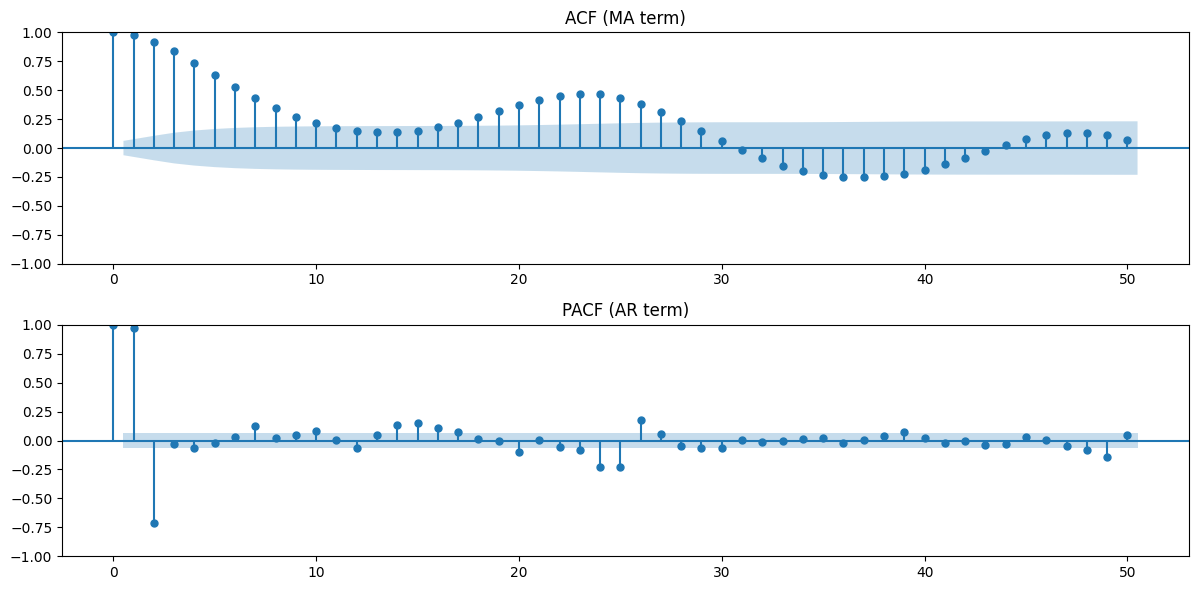

In [23]:
# SARIMA param finding

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_stationarity(ts, lags=50):
    # drop NaNs
    ts = ts[~np.isnan(ts)] if isinstance(ts, np.ndarray) else ts.dropna()
    
    # ADF test
    try:
        stat, p = adfuller(ts)[:2]
        print(f'ADF Statistic: {stat:.4f}, p-value: {p:.4f}')
        print("Stationary " if p < 0.05 else "Non-stationary ")
    except Exception as e:
        print(f"ADF failed: {e}")

    # ACF/PACF plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    plot_acf(ts, ax=ax1, lags=lags, title="ACF (MA term)")
    plot_pacf(ts, ax=ax2, lags=lags, title="PACF (AR term)")
    plt.tight_layout()
    plt.show()

# Example: first 1000 hours of Bus 2, feature 0
sample_series = scaled_tensor[train_idx[:1000], 2, 0]

print("--- Original series ---")
analyze_stationarity(sample_series)

